DataDump attributes: ['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'filename', 'from_pickle', 'get_filename', 'idx', 'interferometers', 'label', 'likelihood_lookup_table', 'likelihood_multiband_weights', 'likelihood_roq_params', 'likelihood_roq_weights', 'meta_data', 'outdir', 'priors_class', 'priors_dict', 'to_pickle', 'trigger_time']

Interferometer list: [Interferometer(name='H1', power_spectral_density=PowerSpectralDensity(psd_file='LIGO_Hanford_PSD.txt', asd_file='None'), minimum_frequency=20.0, maximum_frequency=256.0, length=4.0, latitude=46.45514666666667, longitude=-119.4076571388889, elevation=142.554, xarm_azimuth=125.9994, yarm_azimuth=215.9994, xarm_tilt=-0.0006195, yarm_tilt=1.2

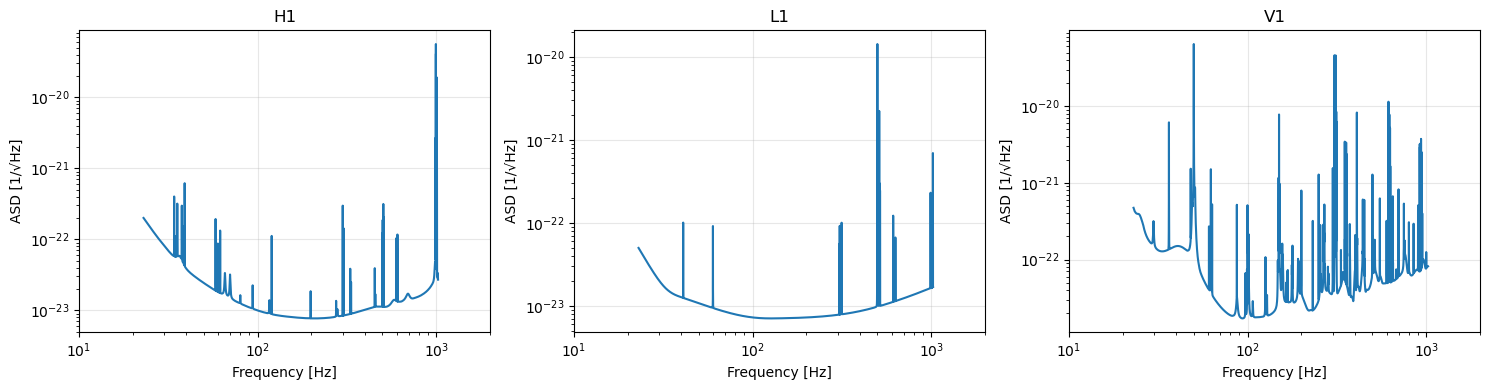


=== PSD Statistics ===

H1:
  Frequency range: 0.00 - 1024.00 Hz
  PSD shape: (316417,)
  Min PSD: 5.90e-47
  Max PSD: inf

L1:
  Frequency range: 0.00 - 1024.00 Hz
  PSD shape: (316417,)
  Min PSD: 4.94e-47
  Max PSD: inf

V1:
  Frequency range: 0.00 - 1024.00 Hz
  PSD shape: (316417,)
  Min PSD: 2.92e-46
  Max PSD: inf


In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Load the data dump
data_file = 'outdir_ecck3PN_Uniform/data/ecck3PN_Uniform_data0_1187008882-43_generation_data_dump.pickle'

with open(data_file, 'rb') as f:
    data_dump = pickle.load(f)

# The data_dump is a DataDump object with attributes
print("DataDump attributes:", dir(data_dump))
print("\nInterferometer list:", data_dump.interferometers)

# Extract PSDs for each detector
ifos = data_dump.interferometers

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ifo in enumerate(ifos):
    ax = axes[i]
    
    # Get PSD
    freq = ifo.frequency_array
    psd = ifo.power_spectral_density_array
    
    # Plot
    ax.loglog(freq, np.sqrt(psd), label=f'{ifo.name} PSD')
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('ASD [1/√Hz]')
    ax.set_title(f'{ifo.name}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(10, 2000)
    
plt.tight_layout()
plt.show()

# Print some PSD statistics
print("\n=== PSD Statistics ===")
for ifo in ifos:
    print(f"\n{ifo.name}:")
    print(f"  Frequency range: {ifo.frequency_array[0]:.2f} - {ifo.frequency_array[-1]:.2f} Hz")
    print(f"  PSD shape: {ifo.power_spectral_density_array.shape}")
    print(f"  Min PSD: {np.min(ifo.power_spectral_density_array):.2e}")
    print(f"  Max PSD: {np.max(ifo.power_spectral_density_array):.2e}")

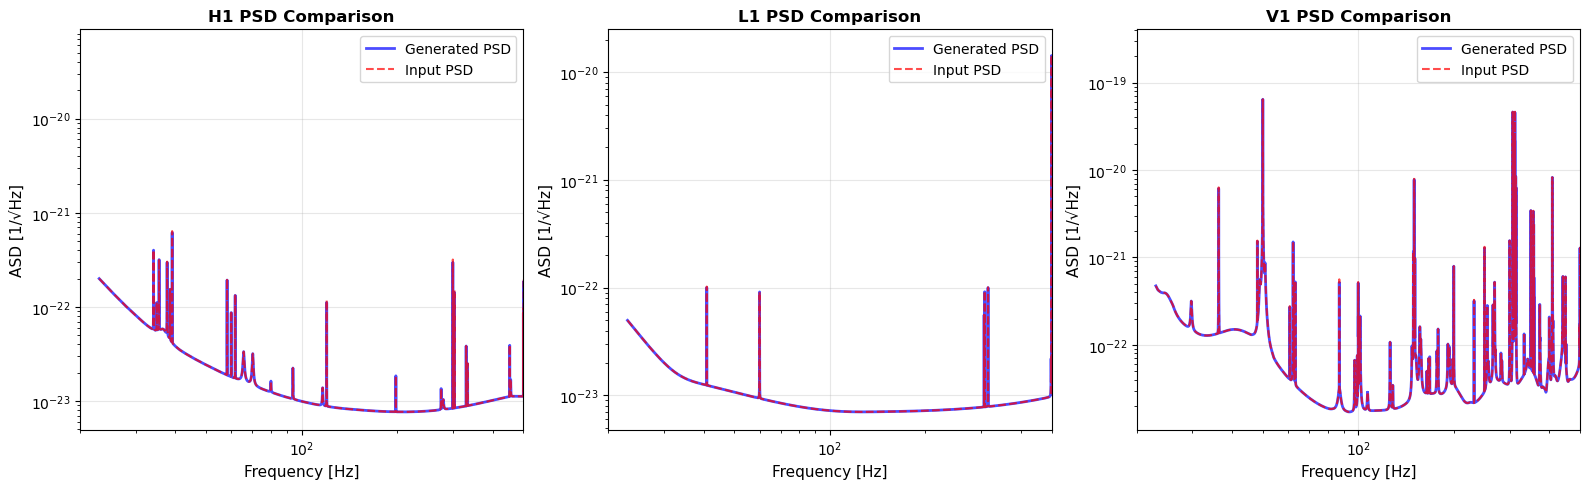


=== Quantitative PSD Comparison ===

H1:
  Input PSD frequency range: 23.00 - 2048.00 Hz
  Generated PSD frequency range: 0.00 - 1024.00 Hz
  Mean relative difference: 0.0000e+00
  Median relative difference: 0.0000e+00
  Max relative difference: 0.0000e+00
  95th percentile relative difference: 0.0000e+00

L1:
  Input PSD frequency range: 23.00 - 2048.00 Hz
  Generated PSD frequency range: 0.00 - 1024.00 Hz
  Mean relative difference: 0.0000e+00
  Median relative difference: 0.0000e+00
  Max relative difference: 0.0000e+00
  95th percentile relative difference: 0.0000e+00

V1:
  Input PSD frequency range: 23.00 - 2048.00 Hz
  Generated PSD frequency range: 0.00 - 1024.00 Hz
  Mean relative difference: 0.0000e+00
  Median relative difference: 0.0000e+00
  Max relative difference: 0.0000e+00
  95th percentile relative difference: 0.0000e+00


In [3]:
# Compare generated PSDs with input PSD files
import numpy as np
import matplotlib.pyplot as plt

# Load input PSD files
psd_files = {
    'H1': 'LIGO_Hanford_PSD.txt',
    'L1': 'LIGO_Livingston_PSD.txt',
    'V1': 'Virgo_PSD.txt'
}

input_psds = {}
for det, filename in psd_files.items():
    data = np.loadtxt(filename)
    input_psds[det] = {
        'frequency': data[:, 0],
        'psd': data[:, 1]
    }

# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, ifo in enumerate(ifos):
    ax = axes[i]
    det_name = ifo.name
    
    # Generated PSD
    gen_freq = ifo.frequency_array
    gen_psd = ifo.power_spectral_density_array
    
    # Input PSD
    inp_freq = input_psds[det_name]['frequency']
    inp_psd = input_psds[det_name]['psd']
    
    # Plot both
    ax.loglog(gen_freq, np.sqrt(gen_psd), 'b-', label='Generated PSD', linewidth=2, alpha=0.7)
    ax.loglog(inp_freq, np.sqrt(inp_psd), 'r--', label='Input PSD', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Frequency [Hz]', fontsize=11)
    ax.set_ylabel('ASD [1/√Hz]', fontsize=11)
    ax.set_title(f'{det_name} PSD Comparison', fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(20, 500)
    
plt.tight_layout()
plt.show()

# Quantitative comparison: interpolate and compute differences
print("\n=== Quantitative PSD Comparison ===")
for ifo in ifos:
    det_name = ifo.name
    
    # Generated PSD
    gen_freq = ifo.frequency_array
    gen_psd = ifo.power_spectral_density_array
    
    # Input PSD
    inp_freq = input_psds[det_name]['frequency']
    inp_psd = input_psds[det_name]['psd']
    
    # Interpolate input PSD to generated frequency grid
    inp_psd_interp = np.interp(gen_freq, inp_freq, inp_psd)
    
    # Compute relative differences (where both are defined)
    mask = (gen_freq >= inp_freq.min()) & (gen_freq <= inp_freq.max())
    rel_diff = np.abs(gen_psd[mask] - inp_psd_interp[mask]) / inp_psd_interp[mask]
    
    print(f"\n{det_name}:")
    print(f"  Input PSD frequency range: {inp_freq.min():.2f} - {inp_freq.max():.2f} Hz")
    print(f"  Generated PSD frequency range: {gen_freq.min():.2f} - {gen_freq.max():.2f} Hz")
    print(f"  Mean relative difference: {np.mean(rel_diff):.4e}")
    print(f"  Median relative difference: {np.median(rel_diff):.4e}")
    print(f"  Max relative difference: {np.max(rel_diff):.4e}")
    print(f"  95th percentile relative difference: {np.percentile(rel_diff, 95):.4e}")